# Convolutional Neural Networks

## Introduction   

Convolutional Neural Networks (CNNs), build upon the fully connected neural networks you've seen to date. Since detailed images can have incredibly high dimensions based on the number of pixels, CNNs provide an alternative formulation for analyzing groups of pixels. Without the convolutional operation, fitting neural networks to medium to large images would be infeasible for all but the most powerful computers. For example, given a color image with 500 x 500 pixels, you would have 500 x 500 x 3 = 750,000 input features, $(x_1,...,x_{750,000})$. 
From there, even having 2000 hidden units (3% of the input), in the first hidden layer, would result in roughly 1.5 billion parameters!

CNNs have certain features that identify patterns in images because of "convolution operation" including:

- Dense layers learn global patterns in their input feature space

- Convolution layers learn local patterns, and this leads to the following interesting features:
    - Unlike with densely connected networks, when a convolutional neural network recognizes a pattern in one region, these insights can be shared and applied to other regions.
    - Deeper convolutional neural networks can learn spatial hierarchies. A first layer will learn small local patterns, a second layer will learn larger patterns using features of the first layer patterns, etc. 
     
Because of these properties, CNNs are great for tasks like: 

- Image classification
- Object detection in images
- Picture neural style transfer

## Objectives

You will be able to:

- Define what a convolution is, as it relates to CNNs 
- Explain how convolutions work using RGB images 
- Describe what a pooling layer is in a neural network 
- Explain how padding works with convolution layers of a neural network 

## Building CNNs in Keras

Building a CNN in Keras is very similar to the previous neural networks that you've built to date. To start, you will initialize a sequential model as before and go on adding layers. However, rather then simply adding additional dense layers or dropouts between them, we will now start to investigate other potential layer architectures including convolutional layers.

<img src="assets/02_convolutional_neural_networks/Image_158CNN.png">

## The Convolution Operation 

The idea behind the convolutional operation is to detect complex building blocks, or features, that can aid in the larger task such as image recognition. For example, we'll detect vertical or horizontal edges present in the image. Let's look at what horizontal edge detection would look like: 

![title](assets/02_convolutional_neural_networks/conv.png)

This is a simplified 5 x 5 pixel image (greyscale!). You use a so-called "filter" (denoted on the right) to perform a convolution operation. This particular filter operation will detect horizontal edges. The matrix in the left should have number in it (from 1-255, or let's assume we rescaled it to number 1-10). The output is a 3 x 3 matrix. (*This example is for computational clarity, no clear edges*)


In Keras, function for the convolution step is `Conv2D`.

The convolutional operation applies this filter (typically 3x3 or 5x5) to each possible 3x3 or 5x5 region of the original image. The graphic below demonstrates this process.  

<img src="assets/02_convolutional_neural_networks/convolution-layer-a.png">

[gif courtesy of Stanford University](https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-convolutional-neural-networks)

## Padding

There are some issues with using filters on images including: 

- The image shrinks with each convolution layer: you're throwing away information in each layer! For example:
    - Starting from a 5 x 5 matrix, and using a 3 x 3 matrix, you end up with a 3 x 3 image  
    - Starting from a 10 x 10 matrix, and using a 3 x 3 matrix, you end up with a 8 x 8 image, etc. 
    
- The pixels around the edges are used much less in the outputs due to the filter   


For example, if you apply 3x3 filters to a 5x5 image, the original 5x5 image contains 25 pixels, but tiling the 3x3 filter only has 9 possible locations. Here's the 4 of the 9 possible locations for the 3x3 filter on a 5x5 image:  

<img src="assets/02_convolutional_neural_networks/5by5_3by3_1.jpeg" width=200>
<img src="assets/02_convolutional_neural_networks/5by5_3by3_2.jpeg" width=200>
<img src="assets/02_convolutional_neural_networks/5by5_3by3_3.jpeg" width=200>
<img src="assets/02_convolutional_neural_networks/5by5_3by3_4.jpeg" width=200>

Fortunately, padding solves both of these problems! Just one layer of pixels around the edges preserves the image size when having a 3 x 3 filter. We can also use bigger filters, but generally the dimensions are odd!

Some further terminology regarding padding that you should be aware of includes:

- "Valid" - no padding
- "Same" - padding such that output is same as the input size

By adding padding to our 5x5 image, (now a 6x6 image by adding a border of pixels) we can add padding so that each pixel of our original 5x5 image can be the center of a 3x3 convolution window filter.

## Strided convolutions

Another method to change the output of your convolutions is to change the stride. The stride is how the convolution filter is moved over the original image. In our above example, we moved the filter one pixel to the right starting from the upper left hand corner, and then began to do this again after moving the filter one pixel down. Alternatively, by changing the stride, we could move our filter by 2 pixels each time, resulting in a smaller number of possible locations for the filter.  

Strided convolutions are rarely used in practice but a good feature to be aware of for some models.

## Convolutions on RGB images

Instead of 5 x 5 grayscale, imagine a 7 x 7 RGB image, which boils down to having a 7 x 7 x 3 tensor. (The image itself is compromised by a 7 by 7 matrix of pixels, each with 3 numerical values for the RGB values.) From there, you will need to use a filter that has the third dimension equal to 3 as well, let's say, 3 x 3 x 3 (a 3D "cube"). 

This allows you to detect horizontal edges in the blue channel.

Then, in each layer, you can convolve with several 3D filters. Afterwards, you stack every output of the result together, giving you a matrix of shape 5 x 5 x `number_of_filters`.

If you think of it, the filter plays the same role as the w^{[1]} in our densely connected networks.

The advantage is, while your image may be huge, the amount of parameters you have still only depends on how many filters you're using!


Imagine 20 (3 x 3 x 3) --> 20 * 27 + a bias for each filter (1* 20) = 560 parameters.

Notation:

- $f^{[l]}$ = size of the filter
- $p^{[l]}$ = padding
- $s^{[l]}$ = amount of stride
- $ n_c^{[l]}$ = number of filters
- filter: $f^{[l]}$ x $f^{[l]}$ x $ n_c^{[l-1]}$


- Input = $ n_h^{[l-1]} * n_w^{[l-1]} * n_c^{[l-1]} $
- Output = $ n_h^{[l]} * n_w^{[l]} * n_c^{[l]} $

Height and width are given by:

$n_h^{[l]}= \Bigr\lfloor\dfrac{n_h^{[l-1]}+2p^{[l]}-f^{[l]}}{s^{[l]}}+1\Bigr\rfloor$

$n_w^{[l]}= \Bigr\lfloor\dfrac{n_w^{[l-1]}+2p^{[l]}-f^{[l]}}{s^{[l]}}+1\Bigr\rfloor$


Activations: $a^{[l]}$ is of dimension $ n_h^{[l]} * n_w^{[l]} * n_c^{[l]} $


## Pooling layer

The last element in a CNN architecture (before fully connected layers as we have previously discussed in other neural networks) is the pooling layer. This layer is meant to substantially downsample the previous convolutional layers. The idea behind this is that the previous convolutional layers will find patterns such as edges or other basic shapes present in the pictures. From there, pooling layers such as Max pooling (the most common) will take a summary of the convolutions from a larger section. In practice, Max pooling (taking the max of all convolutions from a larger area of the original image) works better than average pooling as we are typically looking to detect whether a feature is present in that region. Downsampling is essential in order to produce viable execution times in the model training.

Max pooling has some important hyperparameters:
- $f$ (filter size)
- $S$ (stride)

Common hyperparameters include: `f=2`, `s=2` and `f=3`, `s=2`, this shrinks the size of the representations.
If a feature is detected anywhere in the quadrants, a high number will appear, so max pooling preserves this feature.

## Fully Connected Layers in CNN

Once you have added a number of convolutional layers and pooling layers, you then will add fully connected (dense) layers as we did before in previous neural network models. This now allows the network to learn a final decision function based on these transformed informative inputs generating from the convolutional and pooling layers.

---

## Properly store your images 

When you're analyzing your image data, file management is important. We will be using the santa images again, but this time, they are stored in two folders: `santa` and `not_santa`. We want to work with a `train`, `validation`, and `test` datasets now, as we know by now that this is the best way to obtain unbiased estimate of your model performance.  

Let's import libraries `os` and `shutil`, as we'll need them to create the new folders and move the new files in there.

In [ ]:
import os, shutil

Below we create three objects representing the existing directories: `data/santa/` as `data_santa_dir` and `data/not_santa/` as `data_not_santa_dir`. We will create a new directory `split/` as `new_dir`, where we will split the dataset in three groups (or three subdirectories): `train`, `test`, and `validation`, each containing `santa` and `not_santa` subfolders. The final desired structure is represented below: 

![title](assets/03_convolutional_neural_networks_codealong/folder_structure.png)

In [ ]:
data_santa_dir = 'data/santa/'
data_not_santa_dir = 'data/not_santa/'
new_dir = 'split/'

In [ ]:
print(os.listdir())

['.gitignore', '.ipynb_checkpoints', '.learn', 'CONTRIBUTING.md', 'data', 'images', 'index.ipynb', 'index_files', 'LICENSE.md', 'New folder', 'README.md']


You can use `os.listdir()` to create an object that stores all the relevant image names.

In [ ]:
imgs_santa = [file for file in os.listdir(data_santa_dir) if file.endswith('.jpg')]

In [ ]:
imgs_santa[0:10]

['00000000.jpg',
 '00000001.jpg',
 '00000003.jpg',
 '00000004.jpg',
 '00000005.jpg',
 '00000006.jpg',
 '00000007.jpg',
 '00000008.jpg',
 '00000009.jpg',
 '00000010.jpg']

Let's see how many images there are in the `santa` directory.

In [ ]:
print('There are', len(imgs_santa), 'santa images')

There are 461 santa images


Now, repeat this for the `not_santa` directory:

In [ ]:
imgs_not_santa = [file for file in os.listdir(data_not_santa_dir) if file.endswith('.jpg')]

In [ ]:
print('There are', len(imgs_not_santa), 'images without santa')

There are 461 images without santa


Create all the folders and subfolders in order to get the structure represented above. You can use `os.path.join()` to create strings that will be used later on to generate new directories.

In [ ]:
os.mkdir(new_dir)

In [ ]:
train_folder = os.path.join(new_dir, 'train')
train_santa = os.path.join(train_folder, 'santa')
train_not_santa = os.path.join(train_folder, 'not_santa')

test_folder = os.path.join(new_dir, 'test')
test_santa = os.path.join(test_folder, 'santa')
test_not_santa = os.path.join(test_folder, 'not_santa')

val_folder = os.path.join(new_dir, 'validation')
val_santa = os.path.join(val_folder, 'santa')
val_not_santa = os.path.join(val_folder, 'not_santa')

In [ ]:
train_santa

'split/train\\santa'

Now use all the path strings you created to make new directories. You can use `os.mkdir()` to do this. Go have a look at your directory and see if this worked!

In [ ]:
os.mkdir(test_folder)
os.mkdir(test_santa)
os.mkdir(test_not_santa)

os.mkdir(train_folder)
os.mkdir(train_santa)
os.mkdir(train_not_santa)

os.mkdir(val_folder)
os.mkdir(val_santa)
os.mkdir(val_not_santa)

Copy the Santa images in the three santa subfolders. Let's put the first 271 images in the training set, the next 100 images in the validation set and the final 90 images in the test set.

In [ ]:
# train santa
imgs = imgs_santa[:271]
for img in imgs:
    origin = os.path.join(data_santa_dir, img)
    destination = os.path.join(train_santa, img)
    shutil.copyfile(origin, destination)

In [ ]:
# validation santa
imgs = imgs_santa[271:371]
for img in imgs:
    origin = os.path.join(data_santa_dir, img)
    destination = os.path.join(val_santa, img)
    shutil.copyfile(origin, destination)

In [ ]:
# test santa
imgs = imgs_santa[371:]
for img in imgs:
    origin = os.path.join(data_santa_dir, img)
    destination = os.path.join(test_santa, img)
    shutil.copyfile(origin, destination)

Now, repeat all this for the `not_santa` images!

In [ ]:
# train not_santa
imgs = imgs_not_santa[:271]
for img in imgs:
    origin = os.path.join(data_not_santa_dir, img)
    destination = os.path.join(train_not_santa, img)
    shutil.copyfile(origin, destination)
# validation not_santa
imgs = imgs_not_santa[271:371]
for img in imgs:
    origin = os.path.join(data_not_santa_dir, img)
    destination = os.path.join(val_not_santa, img)
    shutil.copyfile(origin, destination)
# test not_santa
imgs = imgs_not_santa[371:]
for img in imgs:
    origin = os.path.join(data_not_santa_dir, img)
    destination = os.path.join(test_not_santa, img)
    shutil.copyfile(origin, destination)

Let's print out how many images we have in each directory so we know for sure our numbers are right!

In [ ]:
print('There are', len(os.listdir(train_santa)), 'santa images in the training set')

There are 271 santa images in the training set


In [ ]:
print('There are', len(os.listdir(val_santa)), 'santa images in the validation set')

There are 100 santa images in the validation set


In [ ]:
print('There are', len(os.listdir(test_santa)), 'santa images in the test set')

There are 90 santa images in the test set


In [ ]:
print('There are', len(os.listdir(train_not_santa)), 'images without santa in the train set')

There are 271 images without santa in the train set


In [ ]:
print('There are', len(os.listdir(val_not_santa)), 'images without santa in the validation set')

There are 100 images without santa in the validation set


In [ ]:
print('There are', len(os.listdir(test_not_santa)), 'images without santa in the test set')

There are 90 images without santa in the test set


## Use a densely connected network as a baseline

Now that we've a handle on our data, we can easily use Keras' module with image-processing tools. Let's import the necessary libraries below.

In [ ]:
import time
import matplotlib.pyplot as plt
import scipy
import numpy as np
from PIL import Image
from scipy import ndimage
from keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

np.random.seed(123)

Using TensorFlow backend.


In [ ]:
# get all the data in the directory split/test (180 images), and reshape them
test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
        test_folder, 
        target_size=(64, 64), batch_size = 180) 

# get all the data in the directory split/validation (200 images), and reshape them
val_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
        val_folder, 
        target_size=(64, 64), batch_size = 200)

# get all the data in the directory split/train (542 images), and reshape them
train_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
        train_folder, 
        target_size=(64, 64), batch_size=542)

Found 180 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Found 542 images belonging to 2 classes.


In [ ]:
# create the data sets
train_images, train_labels = next(train_generator)
test_images, test_labels = next(test_generator)
val_images, val_labels = next(val_generator)

In [ ]:
# Explore your dataset again
m_train = train_images.shape[0]
num_px = train_images.shape[1]
m_test = test_images.shape[0]
m_val = val_images.shape[0]

print ("Number of training samples: " + str(m_train))
print ("Number of testing samples: " + str(m_test))
print ("Number of validation samples: " + str(m_val))
print ("train_images shape: " + str(train_images.shape))
print ("train_labels shape: " + str(train_labels.shape))
print ("test_images shape: " + str(test_images.shape))
print ("test_labels shape: " + str(test_labels.shape))
print ("val_images shape: " + str(val_images.shape))
print ("val_labels shape: " + str(val_labels.shape))

Number of training samples: 542
Number of testing samples: 180
Number of validation samples: 200
train_images shape: (542, 64, 64, 3)
train_labels shape: (542, 2)
test_images shape: (180, 64, 64, 3)
test_labels shape: (180, 2)
val_images shape: (200, 64, 64, 3)
val_labels shape: (200, 2)


In [ ]:
train_img = train_images.reshape(train_images.shape[0], -1)
test_img = test_images.reshape(test_images.shape[0], -1)
val_img = val_images.reshape(val_images.shape[0], -1)

print(train_img.shape)
print(test_img.shape)
print(val_img.shape)

(542, 12288)
(180, 12288)
(200, 12288)


In [ ]:
train_y = np.reshape(train_labels[:,0], (542,1))
test_y = np.reshape(test_labels[:,0], (180,1))
val_y = np.reshape(val_labels[:,0], (200,1))

In [ ]:
# Build a baseline fully connected model
from keras import models
from keras import layers
np.random.seed(123)
model = models.Sequential()
model.add(layers.Dense(20, activation='relu', input_shape=(12288,))) # 2 hidden layers
model.add(layers.Dense(7, activation='relu'))
model.add(layers.Dense(5, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

In [ ]:
model.compile(optimizer='sgd',
              loss='binary_crossentropy',
              metrics=['accuracy'])

histoire = model.fit(train_img,
                    train_y,
                    epochs=50,
                    batch_size=32,
                    validation_data=(val_img, val_y))

Epoch 1/50
17/17 [==============================] - 0s 10ms/step - loss: 0.6811 - accuracy: 0.5369 - val_loss: 0.6716 - val_accuracy: 0.5100
Epoch 2/50
17/17 [==============================] - 0s 4ms/step - loss: 0.6577 - accuracy: 0.5369 - val_loss: 0.6593 - val_accuracy: 0.7050
Epoch 3/50
17/17 [==============================] - 0s 4ms/step - loss: 0.6405 - accuracy: 0.6494 - val_loss: 0.6421 - val_accuracy: 0.5350
Epoch 4/50
17/17 [==============================] - 0s 3ms/step - loss: 0.6351 - accuracy: 0.5867 - val_loss: 0.6619 - val_accuracy: 0.7000
Epoch 5/50
17/17 [==============================] - 0s 3ms/step - loss: 0.5961 - accuracy: 0.6790 - val_loss: 0.6932 - val_accuracy: 0.5850
Epoch 6/50
17/17 [==============================] - 0s 4ms/step - loss: 0.5918 - accuracy: 0.6661 - val_loss: 0.6113 - val_accuracy: 0.5350
Epoch 7/50
17/17 [==============================] - 0s 4ms/step - loss: 0.5701 - accuracy: 0.6993 - val_loss: 0.5970 - val_accuracy: 0.5550
Epoch 8/50
17/17 [=

In [ ]:
results_train = model.evaluate(train_img, train_y)

17/17 [==============================] - 0s 1ms/step - loss: 0.0981 - accuracy: 0.9815


In [ ]:
results_test = model.evaluate(test_img, test_y)

6/6 [==============================] - 0s 1ms/step - loss: 0.5434 - accuracy: 0.7667


In [ ]:
results_train

[0.09805582463741302, 0.9815497994422913]

In [ ]:
results_test

[0.5434306263923645, 0.7666666507720947]

Remember that, in our previous lab on building deeper neural networks from scratch, we obtained a training accuracy of 95%, and a test set accuracy of 74.23%. 

This result is similar to what we got building our manual "deeper" dense model. The results are not entirely different. This is not a surprise!
- Before, we only had a training and a validation set (which was at the same time the test set). Now we have split up the data 3-ways.
- We didn't use minibatches before, yet we used mini-batches of 32 units here.
 
## Build a CNN

In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
                        input_shape=(64 ,64,  3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(32, (4, 4), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer="sgd",
              metrics=['acc'])

In [ ]:
history = model.fit(train_images,
                    train_y,
                    epochs=30,
                    batch_size=32,
                    validation_data=(val_images, val_y))

Epoch 1/30
17/17 [==============================] - 1s 68ms/step - loss: 0.6898 - acc: 0.5055 - val_loss: 0.6766 - val_acc: 0.5000
Epoch 2/30
17/17 [==============================] - 1s 64ms/step - loss: 0.6770 - acc: 0.5000 - val_loss: 0.6656 - val_acc: 0.5000
Epoch 3/30
17/17 [==============================] - 1s 64ms/step - loss: 0.6683 - acc: 0.5000 - val_loss: 0.6567 - val_acc: 0.5000
Epoch 4/30
17/17 [==============================] - 1s 63ms/step - loss: 0.6594 - acc: 0.5037 - val_loss: 0.6486 - val_acc: 0.5150
Epoch 5/30
17/17 [==============================] - 1s 64ms/step - loss: 0.6487 - acc: 0.5314 - val_loss: 0.6343 - val_acc: 0.5100
Epoch 6/30
17/17 [==============================] - 1s 64ms/step - loss: 0.6371 - acc: 0.5738 - val_loss: 0.6198 - val_acc: 0.5450
Epoch 7/30
17/17 [==============================] - 1s 66ms/step - loss: 0.6194 - acc: 0.6494 - val_loss: 0.6010 - val_acc: 0.6200
Epoch 8/30
17/17 [==============================] - 1s 63ms/step - loss: 0.5992 - a

In [ ]:
results_train = model.evaluate(train_images, train_y)

17/17 [==============================] - 0s 14ms/step - loss: 0.2037 - acc: 0.9225


In [ ]:
results_test = model.evaluate(test_images, test_y)

6/6 [==============================] - 0s 12ms/step - loss: 0.3298 - acc: 0.8500


In [ ]:
results_train

[0.20373380184173584, 0.9225092530250549]

In [ ]:
results_test

[0.32978400588035583, 0.8500000238418579]

## Data Augmentation

`ImageDataGenerator()` becomes really useful when we *actually* want to generate more data. We'll show you how this works.

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255, 
                                   rotation_range=40, 
                                   width_shift_range=0.2, 
                                   height_shift_range=0.2, 
                                   shear_range=0.3, 
                                   zoom_range=0.1, 
                                   horizontal_flip=False)

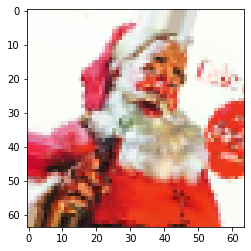

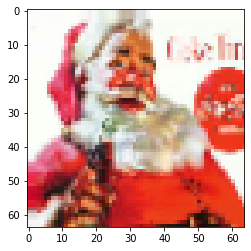

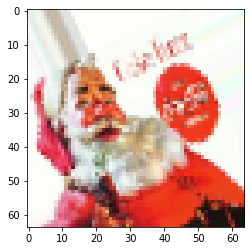

In [ ]:
names = [os.path.join(train_santa, name) for name in os.listdir(train_santa)]
img_path = names[91]
img = load_img(img_path, target_size=(64, 64))

reshape_img = img_to_array(img) 
reshape_img = reshape_img.reshape((1,) + reshape_img.shape) 
i=0
for batch in train_datagen.flow(reshape_img, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(array_to_img(batch[0]))
    i += 1
    if i % 3 == 0:
        break
plt.show()

In [ ]:
# get all the data in the directory split/test (180 images), and reshape them
test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
        test_folder, 
        target_size=(64, 64), 
        batch_size = 180,
        class_mode='binary') 

# get all the data in the directory split/validation (200 images), and reshape them
val_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
        val_folder, 
        target_size=(64, 64),
        batch_size = 32,
        class_mode='binary')

# get all the data in the directory split/train (542 images), and reshape them
train_generator = train_datagen.flow_from_directory(
        train_folder, 
        target_size=(64, 64), 
        batch_size = 32, 
        class_mode='binary')

Found 180 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Found 542 images belonging to 2 classes.


In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
                        input_shape=(64 ,64,  3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(32, (4, 4), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer= 'sgd',
              metrics=['acc'])

In [ ]:
history_2 = model.fit_generator(train_generator, 
                                steps_per_epoch=25, 
                                epochs=30, 
                                validation_data=val_generator, 
                                validation_steps=25)

Epoch 1/30
17/25 [===================>..........] - ETA: 3s - loss: 0.6807 - acc: 0.5018

W0623 00:16:44.135969 27752 data_adapter.py:1153] Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches (in this case, 750 batches). You may need to use the repeat() function when building your dataset.
W0623 00:16:47.445120 27752 data_adapter.py:1153] Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches (in this case, 25 batches). You may need to use the repeat() function when building your dataset.


17/25 [===================>..........] - 11s 629ms/step - loss: 0.6807 - acc: 0.5018 - val_loss: 0.6728 - val_acc: 0.5000


In [ ]:
test_x, test_y = next(test_generator)

In [ ]:
results_test = model.evaluate(test_x, test_y)

180/180 [==============================] - 0s 1ms/step


In [ ]:
results_test

[0.2512160725063748, 0.9277777751286824]

---

## Loading the Images

The data for this lab concerns lung xray images for pneumonia. The original dataset is from Kaggle. We have downsampled this dataset in order to reduce training time for you when you design and fit your model to the data. ⏰ It is anticipated that this process will take approximately one hour to run on a standard machine, although times will vary depending on your particular computer and set up. At the end of this lab, you are welcome to try training on the complete dataset and observe the impact on the model's overall accuracy. 

You can find the initial downsampled dataset in a subdirectory, **chest_xray**, of this repository.

In [ ]:
from keras.preprocessing.image import ImageDataGenerator
import datetime

original_start = datetime.datetime.now()
start = datetime.datetime.now()

Using TensorFlow backend.


In [ ]:
# Load the images; be sure to also preprocess these into tensors 

train_dir = 'data/chest_xray_downsampled/train'
validation_dir = 'data/chest_xray_downsampled/val/'
test_dir = 'data/chest_xray_downsampled/test/' 

# All images will be rescaled by 1./255
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        # This is the target directory
        train_dir,
        # All images will be resized to 150x150
        target_size=(150, 150),
        batch_size=20,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='binary')

validation_generator = test_datagen.flow_from_directory(validation_dir,
                                                        target_size=(150, 150),
                                                        batch_size=20,
                                                        class_mode='binary')

Found 1738 images belonging to 2 classes.
Found 4 images belonging to 2 classes.


## Designing the Model

Now it's time to design your CNN using Keras! Remember a few things when doing this: 

- You should alternate convolutional and pooling layers
- You should have later layers have a larger number of parameters in order to detect more abstract patterns
- Add some final dense layers to add a classifier to the convolutional base 
- Compile this model

In [ ]:
# Your code here; design and compile the model
from  keras import layers
from  keras import models

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
                        input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

In [ ]:
from  keras import optimizers

model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(lr=1e-4),
              metrics=['acc'])

## Training and Evaluating the Model

Remember that training deep networks is resource intensive: depending on the size of the data, even a CNN with 3-4 successive convolutional and pooling layers is apt to take a hours to train on a high end laptop. Using 30 epochs and 8 layers (alternating between convolutional and pooling), our model took about 40 minutes to run on a year old macbook pro.


If you are concerned with runtime, you may want to set your model to run the training epochs overnight.  

**If you are going to run this process overnight, be sure to also script code for the following questions concerning data augmentation. Check your code twice (or more) and then set the notebook to run all, or something equivalent to have them train overnight.**

In [ ]:
# Set the model to train 
# ⏰ This cell may take several minutes to run 
history = model.fit_generator(train_generator, 
                              steps_per_epoch=10, #100
                              epochs=3, # 30
                              validation_data=validation_generator, 
                              validation_steps=5) # 50

Epoch 1/3
10/10 [==============================] - 22s 2s/step - loss: 0.6322 - acc: 0.7250 - val_loss: 0.7034 - val_acc: 0.5000
Epoch 2/3
10/10 [==============================] - 23s 2s/step - loss: 0.5758 - acc: 0.7350 - val_loss: 0.8298 - val_acc: 0.5000
Epoch 3/3
10/10 [==============================] - 21s 2s/step - loss: 0.5444 - acc: 0.7450 - val_loss: 0.6678 - val_acc: 0.7500


In [ ]:
history.history.keys()

dict_keys(['val_loss', 'val_acc', 'loss', 'acc'])

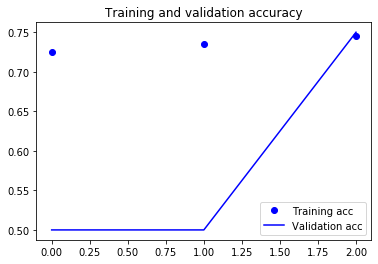

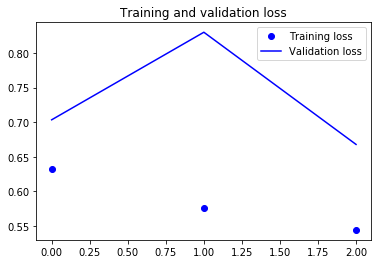

In [ ]:
# Plot history
import matplotlib.pyplot as plt
%matplotlib inline

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(acc))
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [ ]:
end = datetime.datetime.now()
elapsed = end - start
print('Training took a total of {}'.format(elapsed))

Training took a total of 0:01:09.382837


## Save the Model

In [ ]:
# Your code here; save the model for future reference 
model.save('chest_xray_downsampled_data.h5')

## Data Augmentation

Recall that data augmentation is typically always a necessary step when using a small dataset as this one which you have been provided. As such, if you haven't already, implement a data augmentation setup.

**Warning: ⏰ This process took nearly 4 hours to run on a relatively new macbook pro. As such, it is recommended that you simply code the setup and compare to the solution branch, or set the process to run overnight if you do choose to actually run the code.**

In [ ]:
start = datetime.datetime.now()

In [ ]:
# Add data augmentation to the model setup and set the model to train; 
# See warnings above if you intend to run this block of code 
# ⏰ This cell may take several hours to run 
train_datagen = ImageDataGenerator(rotation_range=40, 
                                   width_shift_range=0.2, 
                                   height_shift_range=0.2, 
                                   shear_range=0.2, 
                                   zoom_range=0.2, 
                                   horizontal_flip=True, 
                                   fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        # This is the target directory
        train_dir,
        # All images will be resized to 150x150
        target_size=(150, 150),
        batch_size=32,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='binary')

validation_generator = test_datagen.flow_from_directory(validation_dir, 
                                                        target_size=(150, 150), 
                                                        batch_size=32, 
                                                        class_mode='binary')

history = model.fit_generator(train_generator, 
                              steps_per_epoch=100, 
                              epochs=100, 
                              validation_data=validation_generator, 
                              validation_steps=50)

Found 1738 images belonging to 2 classes.
Found 4 images belonging to 2 classes.
Epoch 1/100
100/100 [==============================] - 369s 4s/step - loss: 11.1548 - acc: 0.3076 - val_loss: 0.7626 - val_acc: 0.5000
Epoch 2/100
100/100 [==============================] - 310s 3s/step - loss: 11.9063 - acc: 0.2613 - val_loss: 0.7626 - val_acc: 0.5000
Epoch 3/100
100/100 [==============================] - 314s 3s/step - loss: 12.0130 - acc: 0.2547 - val_loss: 0.7626 - val_acc: 0.5000
Epoch 4/100
 12/100 [==>...........................] - ETA: 4:23 - loss: 11.7948 - acc: 0.2682

In [ ]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(acc))
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [ ]:
end = datetime.datetime.now()
elapsed = end - start
print('Training with data augmentation took a total of {}'.format(elapsed))

Save the model for future reference.

In [ ]:
# Save the model 
model.save('chest_xray_downsampled_with_augmentation_data.h5')

## Final Evaluation

Now use the test set to perform a final evaluation on your model of choice.

In [ ]:
# Your code here 
# Perform a final evaluation using the test set
test_generator = test_datagen.flow_from_directory(test_dir, 
                                                  target_size=(150, 150), 
                                                  batch_size=20, 
                                                  class_mode='binary')
test_loss, test_acc = model.evaluate_generator(test_generator, steps=50)
print('test acc:', test_acc)

## Level Up (Optional): Adding More Data to the Model

As discussed, the current dataset we worked with is a subset of a dataset hosted on Kaggle. Increasing the data that we use to train the model will result in additional performance gains but will also result in longer training times and be more resource intensive.   

⏰ It is estimated that training on the full dataset will take approximately 4 hours (and potentially significantly longer) depending on your computer's specifications.

In order to test the impact of training on the full dataset, start by downloading the data from Kaggle here: https://www.kaggle.com/paultimothymooney/chest-xray-pneumonia.

In [ ]:
# Optional extension; Your code here
# Imports from above-provided as reference
# from keras import optimizers
# from keras import layers
# from keras import models
# from keras.preprocessing.image import ImageDataGenerator
# import datetime
# import matplotlib.pyplot as plt
# %matplotlib inline 
# ⏰ This cell may take several hours to run 

start = datetime.datetime.now()

train_dir = 'data/chest_xray_downsampled/train'
validation_dir = 'data/chest_xray_downsampled/val/'
test_dir = 'data/chest_xray_downsampled/test/'

# Basic Data Loading; All images will be rescaled by 1./255
# train_datagen = ImageDataGenerator(rescale=1./255)
# test_datagen = ImageDataGenerator(rescale=1./255)

# train_generator = train_datagen.flow_from_directory(
#         # This is the target directory
#         train_dir,
#         # All images will be resized to 150x150
#         target_size=(150, 150),
#         batch_size=20,
#         # Since we use binary_crossentropy loss, we need binary labels
#         class_mode='binary')

# validation_generator = test_datagen.flow_from_directory(
#         validation_dir,
#         target_size=(150, 150),
#         batch_size=20,
#         class_mode='binary')

# With Data Augmentation
train_datagen = ImageDataGenerator(rotation_range=40,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   fill_mode='nearest')

# Never apply data augmentation to test/validation sets 
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        # This is the target directory
        train_dir,
        # All images will be resized to 150x150
        target_size=(150, 150),
        batch_size=32,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='binary')

validation_generator = test_datagen.flow_from_directory(validation_dir,
                                                        target_size=(150, 150),
                                                        batch_size=32,
                                                        class_mode='binary')

# Design Model Architecture
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
                        input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))


model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(lr=1e-4),
              metrics=['acc'])

history = model.fit_generator(train_generator, 
                              steps_per_epoch=100, 
                              epochs=100, 
                              validation_data=validation_generator, 
                              validation_steps=50)


# Viz
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

model.save('chest_xray_all_with_augmentation_data.h5')

end = datetime.datetime.now()
elapsed = end - start
print('Full data model training and evaluation took a total of:\n {}'.format(elapsed))

In [ ]:
test_generator = test_datagen.flow_from_directory(test_dir, 
                                                  target_size=(150, 150), 
                                                  batch_size=20, 
                                                  class_mode='binary')
test_loss, test_acc = model.evaluate_generator(test_generator, steps=50)
print('test acc:', test_acc)

In [ ]:
end = datetime.datetime.now()
elapsed = end - original_start
print('Entire notebook took a total of:\n {}'.format(elapsed))